<a href="https://colab.research.google.com/github/MartaPCastillo/Tesis/blob/main/Grupo%20M%C3%A9xico.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [521]:
!pip install pmdarima

In [522]:
!pip install arch

In [523]:
import pandas as pd
import yfinance as yf # Para descargar datos de acciones
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_pacf
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error
import math
from pmdarima.arima import auto_arima
from sklearn.metrics import mean_absolute_error
from arch import arch_model

#Grupo México

In [524]:
#Obtener datos
df = yf.download('GMEXICOB.MX', start='2024-01-01', end= '2026-06-10')

/tmp/ipykernel_5382/341655575.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download('GMEXICOB.MX', start='2024-01-01', end= '2026-06-10')
[*********************100%***********************]  1 of 1 completed


In [525]:
print(type(df['Close']))

<class 'pandas.core.frame.DataFrame'>


In [526]:
# Eliminar nivel del ticker
df.columns = df.columns.droplevel(1)

#Análisis de la serie

##Medias Móviles

###Media Móvil Simple

In [527]:
#Calcular Media Móvil Simple de 200 días
df['SMA200'] = df['Close'].rolling(window=200).mean()

<Axes: xlabel='Date'>

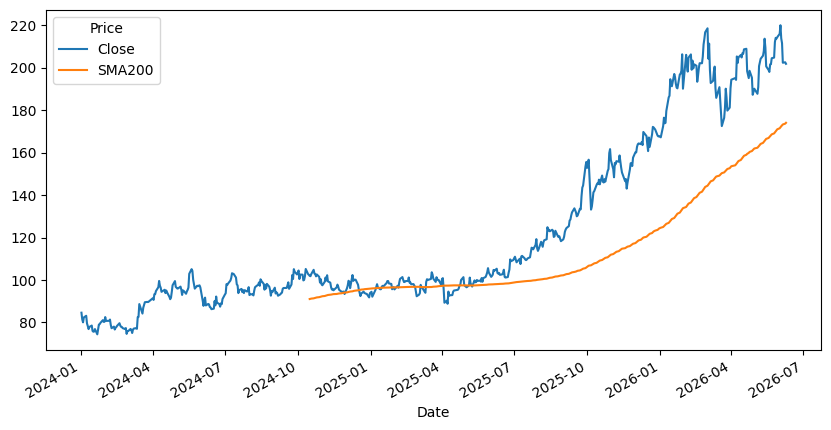

In [528]:
#Visualizar
df[['Close', 'SMA200']].plot(figsize=(10,5))

###Media Móvil Exponencial

In [529]:
#Calcular Media Móvil Exponencial de 200 días
df['EMA200'] = df['Close'].ewm(span=200, adjust=False).mean()

In [530]:
#Calcular Media Móvil Exponencial de 20 días
df['EMA20'] = df['Close'].ewm(span=20, adjust=False).mean()

<Axes: xlabel='Date'>

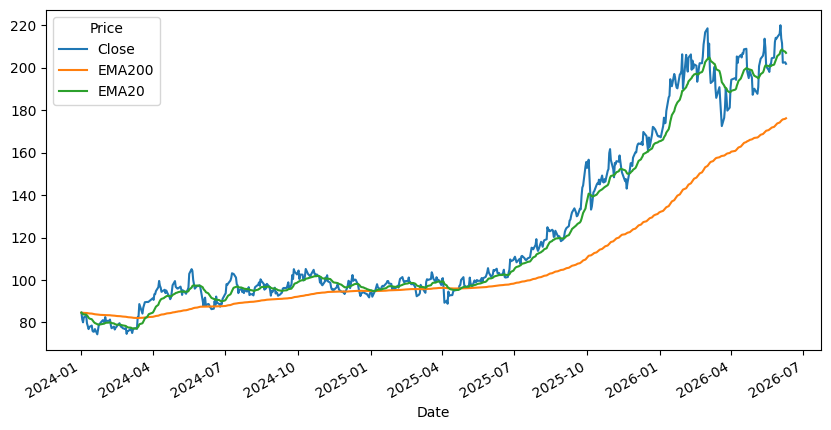

In [531]:
#Visualizar
df[['Close', 'EMA200', 'EMA20']].plot(figsize=(10,5))

##Descomposición Serie Temporal

###Modelo Aditivo

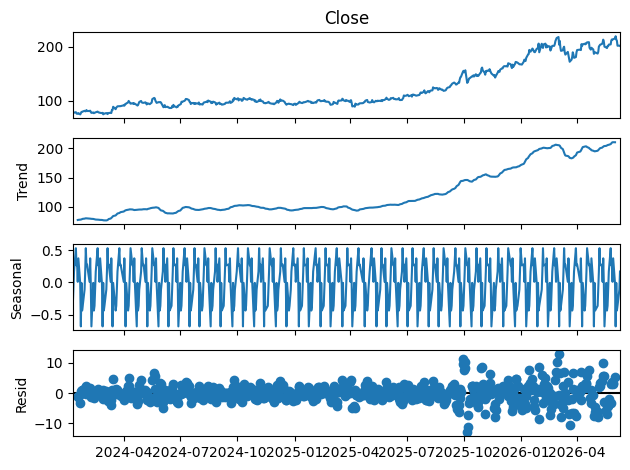

In [442]:
# Descomponer
result = seasonal_decompose(df['Close'], model='additive', period=12) # 12 meses en un año
result.plot()
plt.show()

###Modelo Multiplicativo

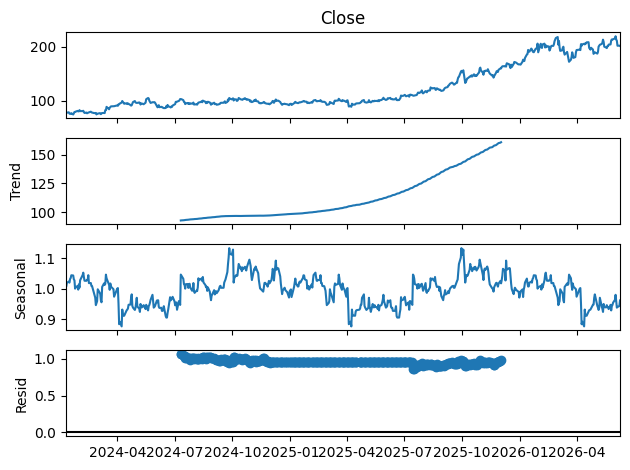

In [443]:
# Descomponer
result = seasonal_decompose(df['Close'], model='multiplicative', period=252) # 252 días hábiles en un año
result.plot()
plt.show()

#Volatilidad

##Desviación Estándar

In [444]:
#Obtener datos
precios = df['Close']

In [445]:
# Método financiero estándar para rendimientos logarítmicos
df['Rendimientos_Log'] = np.log(precios / precios.shift(1))
print(df['Rendimientos_Log'])

Date
2024-01-10         NaN
2024-01-11   -0.018428
2024-01-12    0.012633
2024-01-15    0.008680
2024-01-16   -0.032559
                ...   
2026-06-03   -0.028553
2026-06-04   -0.010631
2026-06-05   -0.044484
2026-06-08    0.001087
2026-06-09   -0.003562
Name: Rendimientos_Log, Length: 603, dtype: float64


In [446]:
#Eliminar NaN solo de rendimientos
df.dropna(subset=['Rendimientos_Log'], inplace=True)
print(df['Rendimientos_Log'])

Date
2024-01-11   -0.018428
2024-01-12    0.012633
2024-01-15    0.008680
2024-01-16   -0.032559
2024-01-17   -0.004893
                ...   
2026-06-03   -0.028553
2026-06-04   -0.010631
2026-06-05   -0.044484
2026-06-08    0.001087
2026-06-09   -0.003562
Name: Rendimientos_Log, Length: 602, dtype: float64


In [447]:
#Calcular la desviación estándar de los rendimientos (Volatilidad Diaria)
volatilidad_diaria = df['Rendimientos_Log'].std()

In [448]:
#Anualizar la volatilidad (multiplicando por la raíz cuadrada de 252 días hábiles al año)
volatilidad_anual = volatilidad_diaria * np.sqrt(252)

In [449]:
Volatilidad_diaria_porcentaje = volatilidad_diaria * 100
Volatilidad_anual_porcentaje = volatilidad_anual * 100

In [450]:
print(f"Volatilidad diaria: {volatilidad_diaria:.4f} = {Volatilidad_diaria_porcentaje:.4f} %")
print(f"Volatilidad anualizada: {volatilidad_anual:.4f} = {Volatilidad_anual_porcentaje:.4f} %")

Volatilidad diaria: 0.0222 = 2.2174 %
Volatilidad anualizada: 0.3520 = 35.2000 %


##Average True Range

In [451]:
#Calcular los 3 componentes del True Range (TR)
high_low = df['High'] - df['Low']
high_close = np.abs(df['High'] - df['Close'].shift(1))
low_close = np.abs(df['Low'] - df['Close'].shift(1))

In [452]:
print(high_low)

Date
2024-01-11    1.783301
2024-01-12    2.272134
2024-01-15    0.724188
2024-01-16    2.444131
2024-01-17    1.738044
                ...   
2026-06-03    6.209991
2026-06-04    7.380005
2026-06-05    8.479996
2026-06-08    4.629990
2026-06-09    8.199997
Length: 602, dtype: float64


In [453]:
print(high_close)

Date
2024-01-11         NaN
2024-01-12    2.054889
2024-01-15    0.796602
2024-01-16    0.343982
2024-01-17    0.153886
                ...   
2026-06-03    0.279999
2026-06-04    0.610001
2026-06-05    3.300003
2026-06-08    3.539993
2026-06-09    3.529999
Length: 602, dtype: float64


In [454]:
print(low_close)

Date
2024-01-11          NaN
2024-01-12     0.217245
2024-01-15     0.072413
2024-01-16     2.788113
2024-01-17     1.891930
                ...    
2026-06-03     6.489990
2026-06-04     6.770004
2026-06-05    11.779999
2026-06-08     1.089996
2026-06-09     4.669998
Length: 602, dtype: float64


In [455]:
#Unir y obtener el máximo de los 3 para cada día
ranges = pd.concat([high_low, high_close, low_close], axis=1)
true_range = ranges.max(axis=1)

In [456]:
print(true_range)

Date
2024-01-11     1.783301
2024-01-12     2.272134
2024-01-15     0.796602
2024-01-16     2.788113
2024-01-17     1.891930
                ...    
2026-06-03     6.489990
2026-06-04     7.380005
2026-06-05    11.779999
2026-06-08     4.629990
2026-06-09     8.199997
Length: 602, dtype: float64


In [457]:
#Calcular el ATR (suavizado clásico de Wilder, n=14)
atr_period = 14
atr = true_range.copy()

In [458]:
#El primer ATR es la media simple de los primeros 14 días
atr.iloc[atr_period-1] = true_range.iloc[:atr_period].mean()

In [459]:
#Iterar para aplicar la fórmula suavizada
for i in range(atr_period, len(true_range)):
    atr.iloc[i] = (atr.iloc[i-1] * (atr_period - 1) + true_range.iloc[i]) / atr_period

df['ATR_Calculado'] = atr
print(df[['High', 'Low', 'Close', 'ATR_Calculado']].tail())

Price             High         Low       Close  ATR_Calculado
Date                                                         
2026-06-03  219.619995  213.410004  213.710007       7.527991
2026-06-04  214.320007  206.940002  211.449997       7.517421
2026-06-05  208.149994  199.669998  202.250000       7.821890
2026-06-08  205.789993  201.160004  202.470001       7.593897
2026-06-09  206.000000  197.800003  201.750000       7.637190


In [460]:
#ATR diario
atr_diario = atr.mean()
print(f"ATR diario: {atr_diario:.4f}")

ATR diario: 4.2143


In [461]:
#ATR Anualizado
atr_anualizado = atr.mean() * np.sqrt(252)
print(f"ATR anualizado: {atr_anualizado:.4f}")

ATR anualizado: 66.9007


#Parámetros (p,d,q)

##Precios Diferenciados

###Serie Estacionaria


In [462]:
#Obtener datos
precios = df['Close']

In [463]:
# Función para realizar la prueba de Dickey-Fuller Aumentada
def probar_estacionariedad(serie, titulo):
    print(f"\n--- Prueba ADF para: {titulo} ---")
    resultado = adfuller(serie.dropna())
    estadistico = resultado[0]
    valor_p = resultado[1]
    criticos = resultado[4]

    print(f"Estadístico de Dickey-Fuller: {estadistico:.4f}")
    print(f"Valor p: {valor_p:.4f}")

    if valor_p < 0.05:
        print("Resultado: **La serie es ESTACIONARIA** (p < 0.05, rechazamos H0).")
    else:
        print("Resultado: **La serie NO es ESTACIONARIA** (p >= 0.05, no se rechaza H0).")

    return valor_p

In [464]:
# Ejecutar prueba en Precios (Original)
probar_estacionariedad(precios, "Precios de Cierre (Original)")


--- Prueba ADF para: Precios de Cierre (Original) ---
Estadístico de Dickey-Fuller: -0.0807
Valor p: 0.9513
Resultado: **La serie NO es ESTACIONARIA** (p >= 0.05, no se rechaza H0).


np.float64(0.9513279121302685)

####Diferenciando

In [465]:
# Calcular la primera diferencia del precio de cierre (columna 'Close')
differenced_prices = precios.diff().dropna()

In [466]:
# Mostrar los primeros elementos de la serie diferenciada
print(differenced_prices.head())

Date
2024-01-12    0.977661
2024-01-15    0.678917
2024-01-16   -2.516541
2024-01-17   -0.371147
2024-01-18    0.072418
Name: Close, dtype: float64


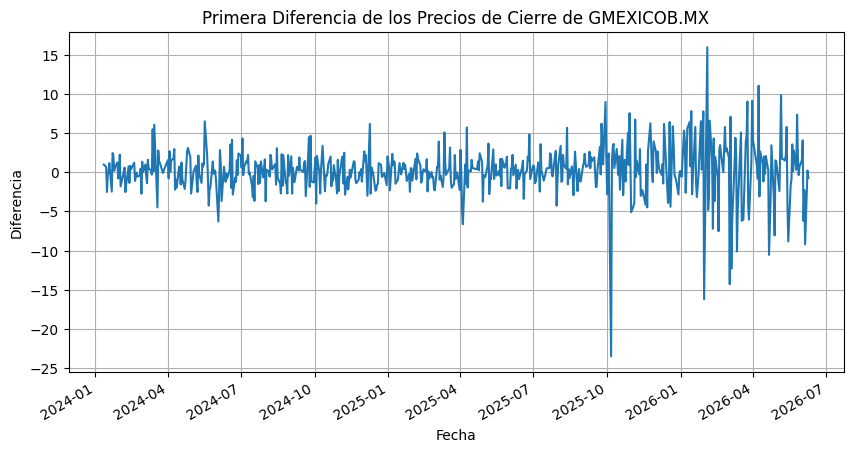

In [467]:
# Visualizar la serie diferenciada
plt.figure(figsize=(10,5))
differenced_prices.plot()
plt.title(f'Primera Diferencia de los Precios de Cierre de {"GMEXICOB.MX"}')
plt.xlabel('Fecha')
plt.ylabel('Diferencia')
plt.grid(True)
plt.show()

In [468]:
# Ejecutar prueba en serie diferenciada
probar_estacionariedad(differenced_prices, "Serie diferenciada")


--- Prueba ADF para: Serie diferenciada ---
Estadístico de Dickey-Fuller: -26.9030
Valor p: 0.0000
Resultado: **La serie es ESTACIONARIA** (p < 0.05, rechazamos H0).


0.0

###Función de Autocorrelación

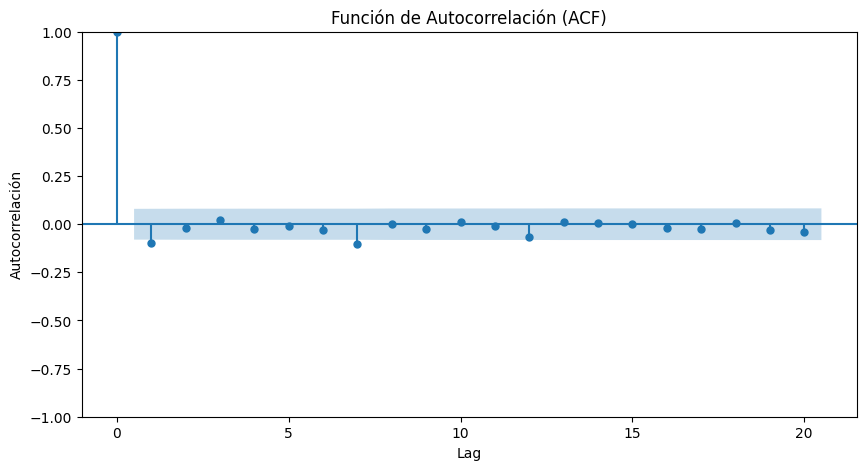

In [469]:
#Graficar la ACF
fig, ax = plt.subplots(figsize=(10, 5))
plot_acf(differenced_prices, lags=20, ax=ax) # Plot first 20 lags
ax.set_xlabel("Lag")
ax.set_ylabel("Autocorrelación")
ax.set_title("Función de Autocorrelación (ACF)")
plt.show()

###Función de Autocorrelación Parcial (PACF)

<Figure size 1000x500 with 0 Axes>

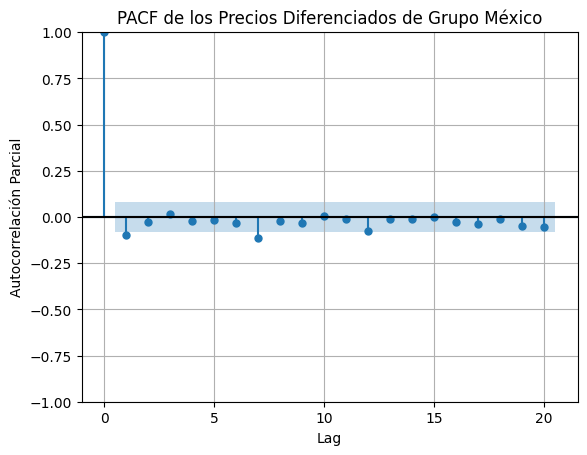

In [470]:
#Graficar la PACF
plt.figure(figsize=(10, 5))
plot_pacf(differenced_prices, lags=20, method='ywm') # method='ywm' es Yule-Walker modificado
plt.title('PACF de los Precios Diferenciados de Grupo México')
plt.xlabel('Lag')
plt.ylabel('Autocorrelación Parcial')
plt.axhline(y=0, color='k', linestyle='-')
plt.grid(True)
plt.show()

##Rendimientos Logarítmicos

In [471]:
# Método financiero estándar para rendimientos logarítmicos
df['Rendimientos_Log'] = np.log(precios / precios.shift(1))
print(df['Rendimientos_Log'])

Date
2024-01-11         NaN
2024-01-12    0.012633
2024-01-15    0.008680
2024-01-16   -0.032559
2024-01-17   -0.004893
                ...   
2026-06-03   -0.028553
2026-06-04   -0.010631
2026-06-05   -0.044484
2026-06-08    0.001087
2026-06-09   -0.003562
Name: Rendimientos_Log, Length: 602, dtype: float64


In [472]:
#Eliminar NaN solo de rendimientos
df.dropna(subset=['Rendimientos_Log'], inplace=True)
print(df['Rendimientos_Log'])

Date
2024-01-12    0.012633
2024-01-15    0.008680
2024-01-16   -0.032559
2024-01-17   -0.004893
2024-01-18    0.000957
                ...   
2026-06-03   -0.028553
2026-06-04   -0.010631
2026-06-05   -0.044484
2026-06-08    0.001087
2026-06-09   -0.003562
Name: Rendimientos_Log, Length: 601, dtype: float64


In [473]:
#Prueba de estacionariedad (Dickey-Fuller Aumentada)
probar_estacionariedad(df['Rendimientos_Log'], "Retornos Logarítmicos")


--- Prueba ADF para: Retornos Logarítmicos ---
Estadístico de Dickey-Fuller: -26.7810
Valor p: 0.0000
Resultado: **La serie es ESTACIONARIA** (p < 0.05, rechazamos H0).


0.0

###Función de Autocorrelación

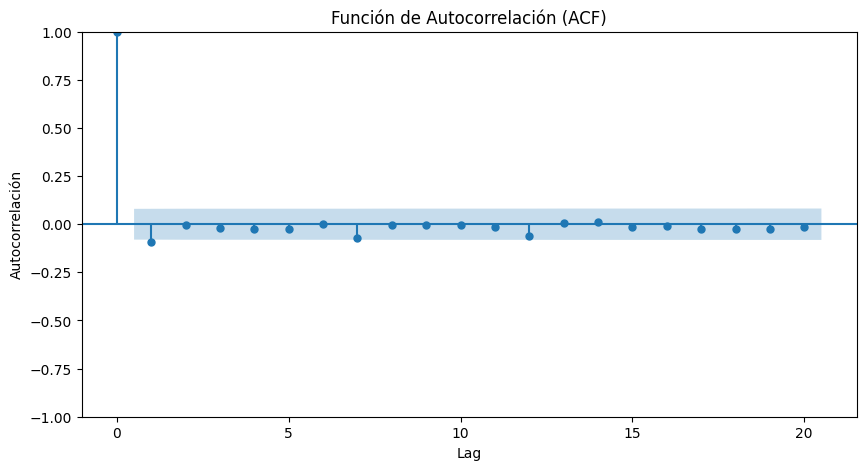

In [474]:
#Gráfica ACF
fig, ax = plt.subplots(figsize=(10, 5))
plot_acf(df['Rendimientos_Log'], lags=20, ax=ax)
ax.set_xlabel("Lag")
ax.set_ylabel("Autocorrelación")
ax.set_title("Función de Autocorrelación (ACF)")
plt.show()

###Función de Autocorrelación Parcial

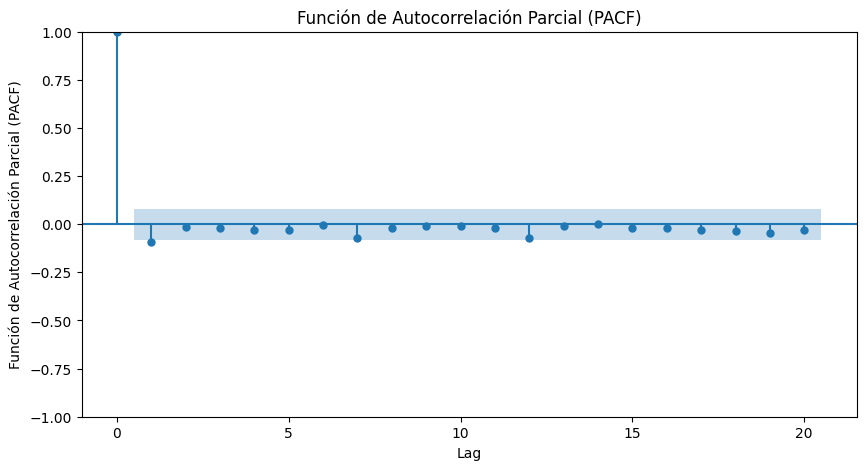

In [475]:
#Gráfica PACF
fig, ax = plt.subplots(figsize=(10, 5))
plot_pacf(df['Rendimientos_Log'], lags=20, ax=ax)
ax.set_xlabel("Lag")
ax.set_ylabel("Función de Autocorrelación Parcial (PACF)")
ax.set_title("Función de Autocorrelación Parcial (PACF)")
plt.show()

#ARIMA

In [476]:
modelo = ARIMA(df['Rendimientos_Log'].dropna(),
               order=(0,0,0))
resultado = modelo.fit()

print(resultado.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:       Rendimientos_Log   No. Observations:                  601
Model:                          ARIMA   Log Likelihood                1436.737
Date:                Wed, 10 Jun 2026   AIC                          -2869.474
Time:                        20:10:23   BIC                          -2860.677
Sample:                             0   HQIC                         -2866.050
                                - 601                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0016      0.001      1.717      0.086      -0.000       0.003
sigma2         0.0005   1.51e-05     32.569      0.000       0.000       0.001
Ljung-Box (L1) (Q):                   4.94   Jarque-

In [477]:
from statsmodels.stats.diagnostic import het_arch

arch_test = het_arch(df['Rendimientos_Log'].dropna())

print("LM Statistic:", arch_test[0])
print("p-value:", arch_test[1])

LM Statistic: 7.668583086710912
p-value: 0.6611730814062245


In [478]:
for orden in [(0,0,0),(1,0,0),(0,0,1),(1,0,1)]:
  modelo = ARIMA(df['Rendimientos_Log'].dropna(),order=orden)
  resultado = modelo.fit()

  print(orden, resultado.aic)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


(0, 0, 0) -2869.4741842354724
(1, 0, 0) -2872.4086718150083


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


(0, 0, 1) -2872.511481495133


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


(1, 0, 1) -2870.5601325610196


In [479]:
modelo = ARIMA(df['Rendimientos_Log'].dropna(),
               order=(0,0,1))

resultado = modelo.fit()

print(resultado.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:       Rendimientos_Log   No. Observations:                  601
Model:                 ARIMA(0, 0, 1)   Log Likelihood                1439.256
Date:                Wed, 10 Jun 2026   AIC                          -2872.511
Time:                        20:10:24   BIC                          -2859.316
Sample:                             0   HQIC                         -2867.375
                                - 601                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0016      0.001      1.893      0.058   -5.62e-05       0.003
ma.L1         -0.0912      0.037     -2.446      0.014      -0.164      -0.018
sigma2         0.0005   1.54e-05     31.603      0.0

In [480]:
residuos = resultado.resid

for lag in [5,10,15,20]:
    lm, pvalue, _, _ = het_arch(residuos, nlags=lag)
    print(f"Lag={lag}: p-value={pvalue}")

Lag=5: p-value=0.44371980504194375
Lag=10: p-value=0.7665680043027104
Lag=15: p-value=0.9312645601665497
Lag=20: p-value=0.9778668652995316


In [481]:
residuos = resultado.resid

In [482]:
garch = arch_model(
    residuos,
    mean='Zero',
    vol='GARCH',
    p=1,
    q=1
)

resultado_garch = garch.fit()
print(resultado_garch.summary())

Iteration:      1,   Func. Count:      5,   Neg. LLF: -1179.4765698575084
Iteration:      2,   Func. Count:     11,   Neg. LLF: -1131.3821100297628
Iteration:      3,   Func. Count:     19,   Neg. LLF: 6755.034271836221
Iteration:      4,   Func. Count:     24,   Neg. LLF: -1440.5199562450362
Iteration:      5,   Func. Count:     33,   Neg. LLF: -1446.8168802983644
Iteration:      6,   Func. Count:     38,   Neg. LLF: -1446.8224563815638
Optimization terminated successfully    (Exit mode 0)
            Current function value: -1446.8225012169519
            Iterations: 6
            Function evaluations: 48
            Gradient evaluations: 6
                       Zero Mean - GARCH Model Results                        
Dep. Variable:                   None   R-squared:                       0.000
Mean Model:                 Zero Mean   Adj. R-squared:                  0.002
Vol Model:                      GARCH   Log-Likelihood:                1446.82
Distribution:                  No

/usr/local/lib/python3.12/dist-packages/arch/univariate/base.py:694: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.0004869. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 100 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  self._check_scale(resids)


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/p

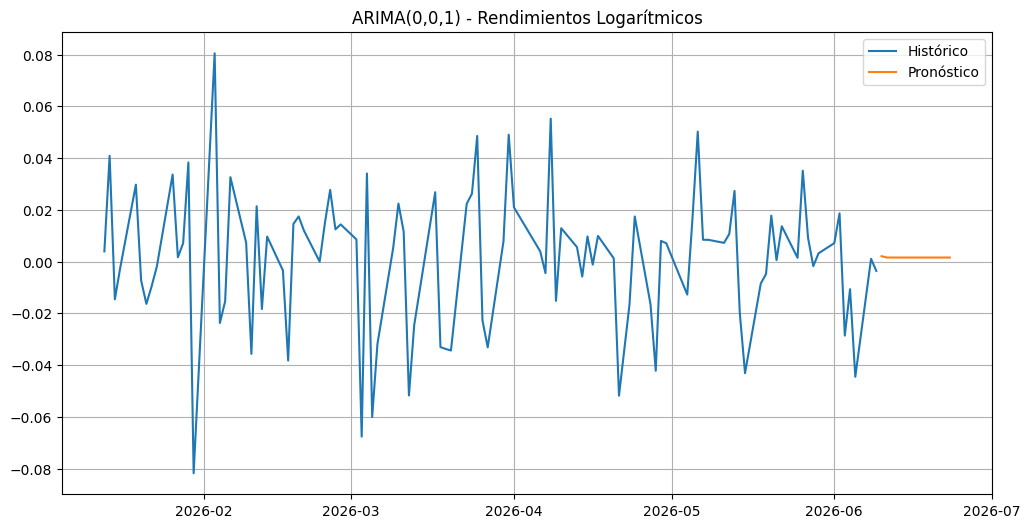

In [483]:
# Ajustar modelo
modelo = ARIMA(df['Rendimientos_Log'].dropna(), order=(0,0,1))
resultado = modelo.fit()

# Pronóstico de 30 días
n_periodos = 10
forecast = resultado.forecast(steps=n_periodos)

# Graficar
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(df.index[-100:],
         df['Rendimientos_Log'].iloc[-100:],
         label='Histórico')

plt.plot(
    pd.date_range(df.index[-1], periods=n_periodos+1, freq='B')[1:],
    forecast,
    label='Pronóstico'
)

plt.title('ARIMA(0,0,1) - Rendimientos Logarítmicos')
plt.legend()
plt.grid(True)
plt.show()

In [484]:
forecast = resultado.forecast(steps=30)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


In [485]:
ultimo_precio = df['Close'].iloc[-1]

In [486]:
precios_pronosticados = [ultimo_precio]

for r in forecast:
    nuevo_precio = precios_pronosticados[-1] * np.exp(r)
    precios_pronosticados.append(nuevo_precio)

precios_pronosticados = precios_pronosticados[1:]

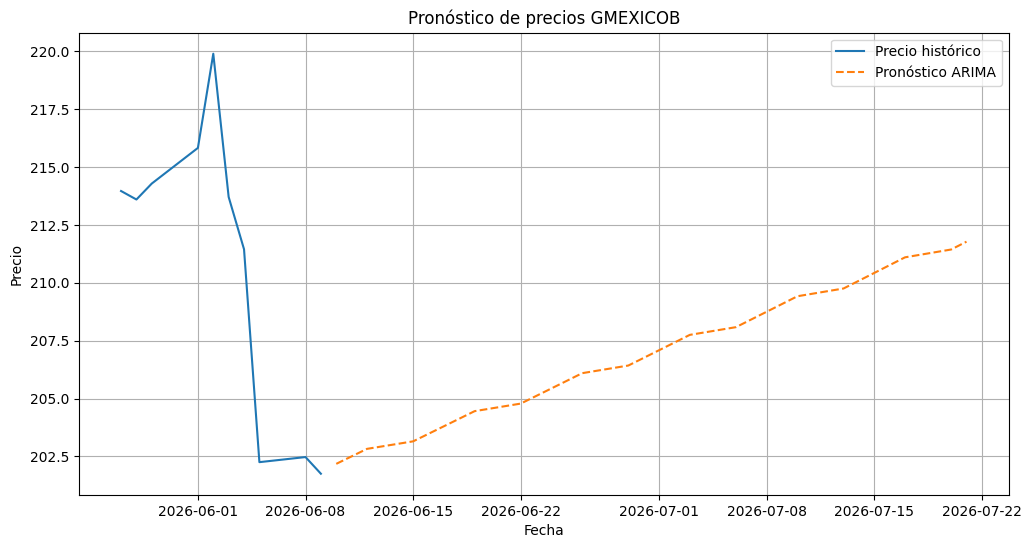

In [487]:
plt.figure(figsize=(12,6))

plt.plot(
    df.index[-10:],
    df['Close'].iloc[-10:],
    label='Precio histórico'
)

fechas_futuras = pd.date_range(
    start=df.index[-1],
    periods=31,
    freq='B'
)[1:]

plt.plot(
    fechas_futuras,
    precios_pronosticados,
    label='Pronóstico ARIMA',
    linestyle='--'
)

plt.title('Pronóstico de precios GMEXICOB')
plt.xlabel('Fecha')
plt.ylabel('Precio')
plt.legend()
plt.grid(True)
plt.show()

In [488]:
#Comparar contra datos reales

# Serie de rendimientos
serie = df['Rendimientos_Log'].dropna()

# Entrenamiento y prueba
train = serie[:-101]
test = serie[-101:]

In [489]:
print(len(train))
print(len(test))

500
101


In [490]:
modelo = ARIMA(train, order=(0,0,1))
resultado = modelo.fit()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


In [491]:
forecast_rend = resultado.forecast(steps=101)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


In [492]:
precios_reales = df['Close'].loc[test.index]

In [493]:
precio_inicial = df['Close'].loc[train.index[-1]]

precios_pred = [precio_inicial]

for r in forecast_rend:
    precios_pred.append(precios_pred[-1] * np.exp(r))

precios_pred = precios_pred[1:]

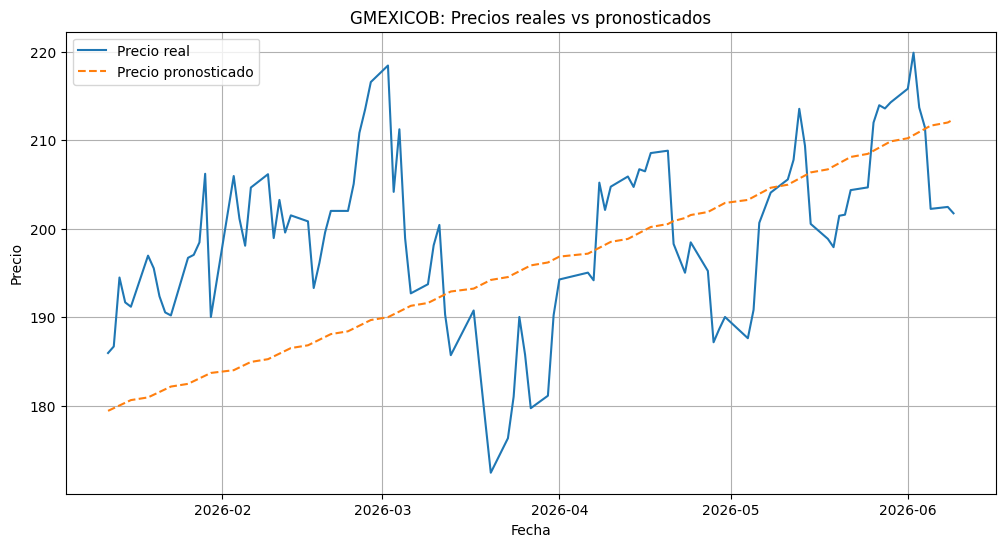

In [494]:
plt.figure(figsize=(12,6))

plt.plot(
    precios_reales.index,
    precios_reales.values,
    label='Precio real'
)

plt.plot(
    precios_reales.index,
    precios_pred,
    '--',
    label='Precio pronosticado'
)

plt.title('GMEXICOB: Precios reales vs pronosticados')
plt.xlabel('Fecha')
plt.ylabel('Precio')
plt.legend()
plt.grid(True)

plt.show()

##RMSE

In [540]:
rmse = np.sqrt(mean_squared_error(precios_reales, precios_pred))
print(f"RMSE = {rmse:.2f}")

RMSE = 11.78


##MAE

In [541]:
mae = mean_absolute_error(precios_reales, precios_pred)
print(f"MAE = {mae: .2f}")

MAE =  9.95


##Error Porcentual Absoluto Medio (MAPE)

In [538]:
# Using scikit-learn
from sklearn.metrics import mean_absolute_percentage_error

mape = mean_absolute_percentage_error(precios_reales, precios_pred) * 100
print(mape)

5.019169077091025


##Auto Arima

In [496]:
Arima = auto_arima(df['Rendimientos_Log'])
print(Arima)

 ARIMA(0,0,1)(0,0,0)[0] intercept


#Monte Carlo

In [497]:
#Calcular los retornos
retornos = df['Rendimientos_Log'].dropna()
print (retornos)

Date
2024-01-12    0.012633
2024-01-15    0.008680
2024-01-16   -0.032559
2024-01-17   -0.004893
2024-01-18    0.000957
                ...   
2026-06-03   -0.028553
2026-06-04   -0.010631
2026-06-05   -0.044484
2026-06-08    0.001087
2026-06-09   -0.003562
Name: Rendimientos_Log, Length: 601, dtype: float64


In [498]:
# Ejecutar prueba en Precios Retornos
probar_estacionariedad(retornos, "Retornos")


--- Prueba ADF para: Retornos ---
Estadístico de Dickey-Fuller: -26.7810
Valor p: 0.0000
Resultado: **La serie es ESTACIONARIA** (p < 0.05, rechazamos H0).


0.0

In [499]:
media_retornos = retornos.mean()
print(f"La media de los retornos es: {media_retornos:.6f}")

La media de los retornos es: 0.001605


In [500]:
#Calculamos la desviación estándar
desviacion_retornos = retornos.std()
print(f"La desviación de los retornos es: {desviacion_retornos:.6f}")

La desviación de los retornos es: 0.022177


In [501]:
# Definir el número de simulaciones (escenarios) y el número de días a proyectar
num_simulaciones = 100 # Número de escenarios Monte Carlo
num_dias_a_proyectar = 100 # Número de días en el futuro para cada simulación

In [502]:
# Obtener el último precio de cierre del DataFrame
ultimo_precio_cierre = df['Close'].iloc[-1]
print("El último precio de cierre es: $", ultimo_precio_cierre)

El último precio de cierre es: $ 201.75


In [503]:
# Lista para almacenar todos los escenarios de precios simulados
monte_carlo_simulaciones = []

In [504]:
for _ in range(num_simulaciones):
    # Para cada simulación, empezar con el último precio conocido
    current_scenario_prices = [ultimo_precio_cierre]
    for _ in range(num_dias_a_proyectar):
        # Generar números aleatorios basado
        aleatorio = np.random.normal(0, 1)
        # Calcular el siguiente precio
        dt = 1/252
        precio_siguiente = current_scenario_prices[-1] * np.exp((media_retornos - 0.5 * desviacion_retornos**2) * dt + desviacion_retornos * np.sqrt(dt) * aleatorio)
        current_scenario_prices.append(precio_siguiente)
    monte_carlo_simulaciones.append(current_scenario_prices)

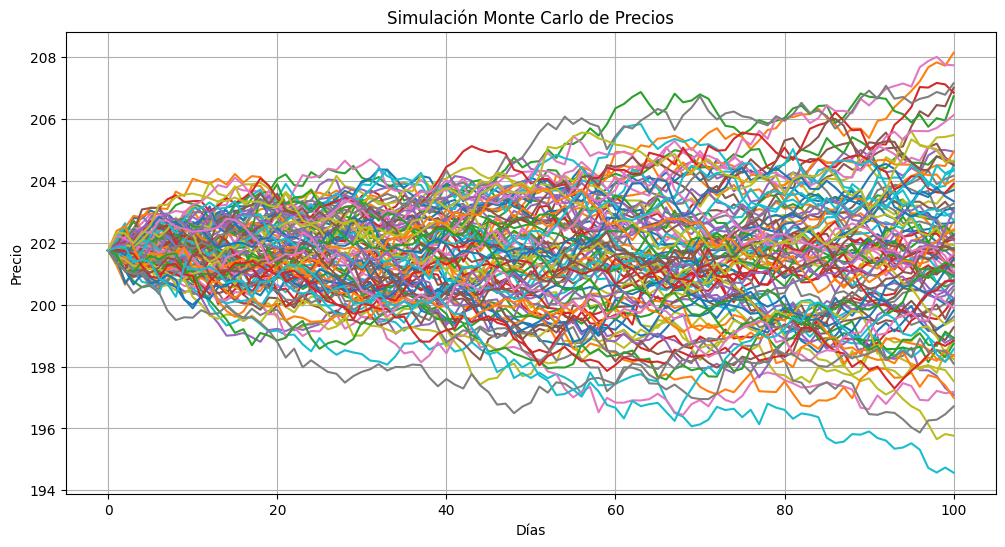

In [505]:
plt.figure(figsize=(12,6))

for simulacion in monte_carlo_simulaciones:
    plt.plot(simulacion)

plt.title('Simulación Monte Carlo de Precios')
plt.xlabel('Días')
plt.ylabel('Precio')
plt.grid(True)

plt.show()

##Predicción precio

In [506]:
# Re-creating monte_carlo_simulaciones_df as a DataFrame
# This assumes 'monte_carlo_simulaciones' is still available from previous cells
monte_carlo_simulaciones_df = pd.DataFrame(monte_carlo_simulaciones).T

In [507]:
# Se extrae la última columna de los precios simulados
ultima_columna = monte_carlo_simulaciones_df.iloc[:,-1]
print(ultima_columna)

0      201.750000
1      201.841273
2      201.861048
3      201.372271
4      201.453158
          ...    
96     199.239164
97     198.976817
98     198.390488
99     198.145729
100    198.565400
Name: 99, Length: 101, dtype: float64


In [508]:
#Precio de cierre número 100
precio_cien = df['Close'][-101]
print(f"El precio de cierre número cien es: $ {precio_cien: .2f}")

El precio de cierre número cien es: $  185.96


/tmp/ipykernel_5382/3328606284.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  precio_cien = df['Close'][-101]


In [509]:
#Calcular Ganancias / Pérdidas

Ganancia_Pérdida = []
for precio in ultima_columna:
    ganancia_perdida = precio - precio_cien
    Ganancia_Pérdida.append(ganancia_perdida)

In [510]:
# Re-creating monte_carlo_simulaciones_df as a DataFrame
# This assumes 'monte_carlo_simulaciones' is still available from previous cells
Ganancia_Pérdida = pd.DataFrame(Ganancia_Pérdida).T
print(Ganancia_Pérdida)

         0          1          2          3          4          5    \
0  15.793015  15.884288  15.904063  15.415286  15.496172  15.420991   

         6          7          8          9    ...        91         92   \
0  14.901468  14.720222  14.294478  15.296255  ...  13.549327  13.753194   

         93         94         95         96         97         98   \
0  13.579628  13.103679  13.038806  13.282178  13.019831  12.433502   

         99         100  
0  12.188743  12.608414  

[1 rows x 101 columns]


In [511]:
#Contar %Ganancias y %Pérdidas si el precio de compra es lo que vale el precio de cierre número cien
if isinstance(Ganancia_Pérdida, list):
    Ganancia_Pérdida = pd.DataFrame(Ganancia_Pérdida).T

Ganancia = (Ganancia_Pérdida > 0).sum().sum()
Perdida = (Ganancia_Pérdida < 0).sum().sum()

# Obtener el número total de simulaciones
num_simulaciones = Ganancia_Pérdida.size

# Calcular porcentajes
porcentaje_ganancia = (Ganancia / num_simulaciones) * 100
porcentaje_perdida = (Perdida / num_simulaciones) * 100

print(f"Número de simulaciones con ganancia: {Ganancia} ({porcentaje_ganancia:.2f} %)")
print(f"Número de simulaciones con pérdida: {Perdida} ({porcentaje_perdida:.2f} %)")
print(f"Número total de simulaciones: {num_simulaciones}")

Número de simulaciones con ganancia: 101 (100.00 %)
Número de simulaciones con pérdida: 0 (0.00 %)
Número total de simulaciones: 101


In [512]:
#Ganancia potencial
Ganancia_potencial = Ganancia_Pérdida.mean(axis=1).iloc[0]
print(f"Ganancia Potencial: $ {Ganancia_potencial: .2f}")

Ganancia Potencial: $  13.33


In [513]:
#Precio Potencial
Precio_potencial = precio_cien + Ganancia_potencial
print(f"Precio Potencial: $ {Precio_potencial: .2f}")

Precio Potencial: $  199.29


##Error Cuadrático Medio (RMSE)


In [514]:
monte_carlo_simulaciones_df = pd.DataFrame(monte_carlo_simulaciones).T

In [515]:
prediccion_mc = monte_carlo_simulaciones_df.mean(axis=1)

In [516]:
ultimos_101 = precios.iloc[-103:-2]
print(ultimos_101)

Date
2026-01-08    173.993454
2026-01-09    179.561325
2026-01-12    185.956985
2026-01-13    186.696091
2026-01-14    194.491104
                 ...    
2026-06-01    215.830002
2026-06-02    219.899994
2026-06-03    213.710007
2026-06-04    211.449997
2026-06-05    202.250000
Name: Close, Length: 101, dtype: float64


In [517]:
print(len(ultimos_101))
print(len(prediccion_mc))

101
101


In [518]:
rmse = np.sqrt(mean_squared_error(ultimos_101, prediccion_mc[0:]))
print(f"RMSE Monte Carlo: {rmse:.4f}")

RMSE Monte Carlo: 10.6063


In [519]:
rmse_porcentaje = (rmse / ultimos_101.mean()) * 100
print(f"% RMSE Monte Carlo: {rmse_porcentaje:.4f} %")

% RMSE Monte Carlo: 5.3403 %


##Error Cuadrático Medio (MAE)

In [520]:
mae = mean_absolute_error(ultimos_101, prediccion_mc)

print(f"MAE Monte Carlo: {mae:.4f}")

MAE Monte Carlo: 8.3187


##Error Porcentual Absoluto Medio (MAPE)

In [536]:
# Using numpy
mape = np.mean(np.absolute((ultimos_101 - prediccion_mc) / ultimos_101)) * 100
print(mape)

nan


/tmp/ipykernel_5382/475056635.py:2: RuntimeWarning: '<' not supported between instances of 'int' and 'Timestamp', sort order is undefined for incomparable objects.
  mape = np.mean(np.absolute((ultimos_101 - prediccion_mc) / ultimos_101)) * 100


In [537]:
# Using scikit-learn
from sklearn.metrics import mean_absolute_percentage_error

mape = mean_absolute_percentage_error(ultimos_101, prediccion_mc) * 100
print(mape)

4.294540631007094
